<a href="https://colab.research.google.com/github/UndeadP0WER/ECMM423/blob/main/ECMM423.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to use this
To obtain the results discussed here, set the INT_SCALE and PSOParameters to the values talked about (where to change them has been pointed out), and run every cell.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn import preprocessing
from tqdm import tqdm

import random

To change the integer scale. do so in the following cell

In [4]:
class LSTMParams:
    #array representation of the params,
    #   hidden_size, num_layers, droput, learn_rate, epochs

    #hidden_size, num_layers and epochs are all ints
    # dropout, learn_rate are all floats between 0 & 1

    #so when exploring hyperparameters, all should be between 0 and 1, and the ints should be scaled by a large number, INT_SCALE, and rounded
    INT_SCALE = 39

    #init from individual values
    #does not need to be scaled from [0,1]
    def __init__(self, hidden_size=5, num_layers=2, dropout=0, learn_rate=0.001, epochs=20):
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.lr = learn_rate
        self.epochs = epochs
        return

    #init from an array
    #previously mentioned variables should be scaled and rounded
    def from_arr(arr):
        p = LSTMParams(
            hidden_size = round(arr[0]*LSTMParams.INT_SCALE)+1,
            num_layers = round(arr[1]*LSTMParams.INT_SCALE)+1,
            dropout = arr[2],
            learn_rate = arr[3],
            epochs = round(arr[4]*LSTMParams.INT_SCALE)+1
            )
        return p


In [5]:

#modelled after https://colab.research.google.com/github/aaubs/ds-master/blob/main/notebooks/M3_LSTM_Tutorial_v3.ipynb#scrollTo=1jyjApvHVkcO

class LSTMModel(nn.Module):
    def __init__(self, output_size=1, params=LSTMParams()):
        super(LSTMModel, self).__init__()
        self.params = params

        self.hidden_size = params.hidden_size
        self.num_layers = params.num_layers

        #loads the data, applies some parameters, prepares for training
        self.prep_data()

        self.lstm = nn.LSTM(self.n_features, params.hidden_size, params.num_layers,
                            batch_first=True, dropout=params.dropout)
        self.fc = nn.Linear(params.hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = out[:, -1, :]  # Last time step
        out = self.fc(out)
        return out


    def create_sequences_multivariate(data, n_timesteps, target_column_index):
        X = []
        y = []
        for i in range(len(data) - n_timesteps):
            seq_x = data[i:i + n_timesteps]
            seq_y = data[i + n_timesteps, target_column_index]
            X.append(seq_x)
            y.append(seq_y)
        return np.array(X), np.array(y)

    def denormalize(scaled_data, scaler, index):
        data = np.zeros((len(scaled_data), scaler.n_features_in_))
        data[:, index] = scaled_data[:, 0]
        data = scaler.inverse_transform(data)
        return data[:, index]

    def prep_data(self):
        ##Preparing data
        #loads data
        data = pd.read_csv('time_series_data.csv', parse_dates=True)
        series = data['Value'].values

        #scale data
        self.scaler = MinMaxScaler(feature_range=(0, 1))
        data_scaled = self.scaler.fit_transform(series.reshape(-1, 1))

        #split into training, testing and validation sets

        train_size = int(len(data_scaled) * 0.8)
        train_data = data_scaled[:train_size]
        test_data = data_scaled[train_size:]

        train_valid_size = int(len(train_data) * 0.8)
        train_data_final = train_data[:train_valid_size]
        valid_data = train_data[train_valid_size:]


        n_timesteps = 1
        self.n_features = data_scaled.shape[1]
        self.target_column_index = 0  # 'Close' is the target column

        # Create sequences for training, validation, and testing
        X_train, y_train = LSTMModel.create_sequences_multivariate(train_data_final, n_timesteps, self.target_column_index)
        X_valid, y_valid = LSTMModel.create_sequences_multivariate(valid_data, n_timesteps, self.target_column_index)
        X_test , y_test  = LSTMModel.create_sequences_multivariate(test_data, n_timesteps, self.target_column_index)

        # Convert to tensors
        X_train = torch.tensor(X_train, dtype=torch.float32)
        y_train = torch.tensor(y_train, dtype=torch.float32)

        X_valid = torch.tensor(X_valid, dtype=torch.float32)
        y_valid = torch.tensor(y_valid, dtype=torch.float32)

        X_test = torch.tensor(X_test, dtype=torch.float32)
        y_test = torch.tensor(y_test, dtype=torch.float32)

        self.Xtest = X_test
        self.ytest = y_test

        # Create DataLoaders
        train_dataset = TensorDataset(X_train, y_train)
        valid_dataset = TensorDataset(X_valid, y_valid)
        test_dataset = TensorDataset(X_test, y_test)

        self.train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
        self.valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
        self.test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


    def train_model(self):
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), lr=self.params.lr)

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)

        train_losses = []
        valid_losses = []


        for epoch in range(self.params.epochs):
            self.train()
            train_loss = 0
            for inputs, targets in self.train_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)

                optimizer.zero_grad()
                # 2. Forward Pass
                outputs = self(inputs)
                # 3. FeedForward Evaluation
                loss = criterion(outputs.squeeze(), targets)
                # 4. Backward Pass / Gradient Calculation
                loss.backward()
                # 5. Back Propagation / Update Weights
                optimizer.step()

                train_loss += loss.item() * inputs.size(0)

            train_loss /= len(self.train_loader.dataset)
            train_losses.append(train_loss)

            # Validation
            self.eval()
            valid_loss = 0
            with torch.no_grad():
                for inputs, targets in self.valid_loader:
                    inputs = inputs.to(device)
                    targets = targets.to(device)
                    outputs = self(inputs)
                    loss = criterion(outputs.squeeze(), targets)
                    valid_loss += loss.item() * inputs.size(0)
            valid_loss /= len(self.valid_loader.dataset)
            valid_losses.append(valid_loss)

            if (epoch + 1) % 2 == 0:
                print(f'Epoch {epoch + 1}/{self.params.epochs}, Train Loss: {train_loss:.6f}, Valid Loss: {valid_loss:.6f}')


        self.eval()
        with torch.no_grad(): # this way prevents PyTorch from storing unnecessary information for backpropagation, making inference faster and more memory-efficient.
            test_preds = self(self.Xtest.to(device)).cpu().numpy()
            test_actuals = self.ytest.numpy()


        test_preds_denorm = LSTMModel.denormalize(test_preds, self.scaler, self.target_column_index)
        test_actuals_denorm = LSTMModel.denormalize(test_actuals.reshape(-1, 1), self.scaler, self.target_column_index)
        return test_preds_denorm, test_actuals_denorm

In [6]:
def generate_dataset(year_count):
    #assume seeding the rng is done before calling

    #generate a date range
    date_range = pd.date_range(start=str(2025-year_count)+'-01-01', end=str(2025)+'-01-01', freq='MS')

    #create synthetic time series data
    trend = np.linspace(0, 10, len(date_range)) ##general trend line across time, long term memory
    seasonal_effect = 10 * np.sin(np.linspace(0, year_count * 2 * np.pi, len(date_range))) # seasonal stuff, short term memory
    noise = np.random.normal(loc=0, scale=1, size=len(date_range)) #random noise
    data = trend + seasonal_effect + noise

    #create a dataframe
    df = pd.DataFrame(data, index=date_range, columns=['Value'])

    #save the data to a file
    df.to_csv('time_series_data.csv')

    #returns the dataframe
    return df


#generates a dataset and then plots it (and saves it)
def setupData(year_count):
    # Plot the synthetic data
    df = generate_dataset(year_count)
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df['Value'], label='Synthetic Data')
    plt.title('Synthetic Time Series Data')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    #plt.savefig("img/dataset.png")
    plt.show()


In [12]:
#Particle Swarm Optimisation
class Particle:
    #best = []
    #cur = []
    #vel = []
    def __init__(self, arr_len):
        #generates a starting position
        #uses float because PSOs operate best on continuous solution space
        #so a binary string is achieved by rounding later on
        #distributed by xi ~ U(blo, bup) (uniform between 0,1)
        self.cur = []
        for i in range(0, arr_len):
            self.cur.append(random.random())
        #best known position is set to starting position
        self.best = self.cur.copy()
        #generates velocity
        #distributed by vi ~ U(-|bup-blo|, |bup-blo|) (uniform between -1,1)
        self.vel = []
        for i in range(0, arr_len):
            self.vel.append((random.random()*2)-1)

        self.bestfit = 0;

    def __str__(self):
        #mostly for testing
        return "best:" + str(self.best) + ",\ncur: " + str(self.cur) + ",\nvel: " + str(self.vel)

class PSOParams:
    def __init__(self, popsize, inertia_weight, cognitive_coeff, social_coeff):
        self.pop = popsize
        self.w = inertia_weight
        self.cc = cognitive_coeff
        self.sc = social_coeff

def particleSwarmOptimisation(arr_len, params, iterations, fitfunct):
    #values for graphing
    gen_fits = [[]]
    gen_best = []

    #init particles distributed uniformly around the solution space
    pop = []
    for p in range(0, params.pop):
        pop.append(Particle(arr_len));

    #sets swarms best known positions
    gbest = pop[0].best.copy()
    gbestfit = fitfunct(gbest)
    gen_best = [gbestfit] #just in case the best is the first one, as it doesnt get updated later if it is

    for p in pop:

        newfit = fitfunct(p.best)
        #sets current best fit for each particle
        p.bestfit = newfit

        #notes current fit for the particle in the generation tracker
        gen_fits[0].append(newfit)

        #if current particle's best is better than the previous global best, replace global best
        if newfit < gbestfit:
            gbest = p.best.copy()
            gbestfit = newfit
            gen_best[0] = newfit


    for iter in range(0, iterations):
        iter_best = gen_best[-1] #sets the iteration best to the previous iterations best - best line can only better solutions
        iter_fits = []

        print("Iteration", iter, "of", iterations)

        for p in pop:
            rp = random.random()
            rg = random.random()
            for i in range(0,arr_len):
                #updates velocity based on: vi,d ← w vi,d + φp rp (pi,d-xi,d) + φg rg (gd-xi,d)
                p.vel[i] = (params.w * p.vel[i]) + (params.cc * rp * (p.best[i] - p.cur[i])) + (params.sc * rg * (gbest[i] - p.cur[i]))

                #updates position
                p.cur[i] = p.cur[i] + p.vel[i]
                #clamps back in range
                if p.cur[i] > 1:
                    p.cur[i] = 1
                elif p.cur[i] < 0:
                    p.cur[i] = 0

            #checks fitness function
            fit = fitfunct(p.cur)
            iter_fits.append(fit)

            if fit < p.bestfit:
                #new particle best
                p.bestfit = fit
                p.best = p.cur.copy()

                if fit < gbestfit:
                    #new global best
                    gbestfit = fit
                    gbest = p.cur.copy()
                    iter_best = fit

        #updates tracking values at the end of the iteration
        gen_best.append(iter_best)
        gen_fits.append(iter_fits)

    return gbest, np.array(gen_best), np.array(gen_fits)

PSO parameters are set here

In [ ]:
random.seed()
setupData(30)
iters = 50
params = PSOParams(10, 0.7, 1.5, 1.5)

In [8]:
#Random Search
def randomSearch(arr_len, iterations, fitfunct):
    #generate initial solution
    best = []
    bestfit = 0

    #graph trackers for analysisng the random search
    all_fits = []
    best_fits = []

    for i in range(0, arr_len):
        best.append(random.random())
        pass
    bestfit = fitfunct(best)
    all_fits.append(bestfit)
    best_fits.append(bestfit)

    #iterates over the random search for the defined number of iterations
    for i in range(0, iterations):

        print("Iteration", i, "of", iterations)

        #generates a competitior solution
        new = []
        for i in range(0, arr_len):
            new.append(random.random())
        #calcs new fitness
        newfit = fitfunct(new)
        #adds to graph tracker
        all_fits.append(newfit)

        #if new solution is a better fit, replace best fit
        if newfit < bestfit:
            best = new
            bestfit = newfit

        best_fits.append(bestfit) #keeps track of the best known at each iteration

    return best, best_fits, all_fits


In [9]:
#Stochastic Hill Climbing
## picks a random neighbouring solution to compare
def hillClimb(arr_len, iterations, fitfunct):
    #generate initial solution
    best = []
    bestfit = 0

    #graph trackers for analysisng the random search
    all_fits = []
    best_fits = []

    for i in range(0, arr_len):
        best.append(random.random())
        pass
    bestfit = fitfunct(best)

    all_fits.append(bestfit)
    best_fits.append(bestfit)

    #iterates over the random search for the defined number of iterations
    for i in range(0, iterations):

        print("Iteration", i, "of", iterations)

        print("best", best, bestfit)
        #generates a competitior solution
        new = best.copy()
        #picks a random position, replaces it with a random selection
        new[int(random.random()*arr_len)] = random.random()

        #calcs new fitness
        newfit = fitfunct(new)
        #adds to graph tracker
        all_fits.append(newfit)

        #if new solution is a better fit, replace best fit
        if newfit < bestfit:
            best = new.copy()
            bestfit = newfit

        best_fits.append(bestfit) #keeps track of the best known at each iteration

    return best, best_fits, all_fits

In [10]:
#fitness functions

#calculates the mean squared error between two arrays
def eval(predicted_arr, actual_arr):
    sum = 0
    for i in range(0, len(predicted_arr)):
        sum += (actual_arr[i] - predicted_arr[i])**2

    sum = sum/len(predicted_arr)
    return sum

#calculates the suitability of a set of hyperparameters by training an LSTM model and evaluating its effectiveness
def lstm_fit(arr):
    params = LSTMParams.from_arr(arr)
    model = LSTMModel(output_size=1, params=params)
    tp, ta = model.train_model()
    return eval(tp, ta)

#gives a random output. useful for testing
def rndfit(arr):
    return random.random()


In [14]:

#takes a 2d array (like whats produced in PSO)
#and flattens it to a 1d array
#and produces an array with the first index of the element
# eg an input of [[1,2,3],[4,5,6]] would produce
# [0,0,0,1,1,1], [1,2,3,4,5,6]
def flatten_w_index(arr_2d):
    y = []
    x = []
    for i in range(0, len(arr_2d)):
        for j in range(0, len(arr_2d[i])):
            x.append(i)
            y.append(arr_2d[i][j])
    return x, y

In [ ]:
 #random search
print("Random Search")
b, bst, pst = randomSearch(5, iters * params.popsize, lstm_fit)
print("best found weights:", b)

plt.figure(figsize=(10, 6))
plt.scatter(np.arange(0,len(pst)), pst)
plt.plot(np.arange(0,len(bst)), bst)

plt.title('Random Search Fitness')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.legend()
#plt.savefig("img/rnd.png")
plt.show()

In [ ]:
#stochastic hill climb
print("Stochastic Hill Climber")
b, bst, pst = hillClimb(5, iters * params.popsize, lstm_fit)
print("best found weights:", b)

plt.figure(figsize=(10, 6))
plt.scatter(np.arange(0,len(pst)), pst)
plt.plot(np.arange(0,len(bst)), bst)

plt.title('Random Search Fitness')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.legend()
#plt.savefig("img/shc.png")
plt.show()

Tests are performed here

PSO:

In [ ]:
#PSO
b, bst, pst = particleSwarmOptimisation(5, params, iters, lstm_fit)
print("best found weights:", b)

#saves data to file - NOT RELEVANT TO COLABS
#obj = (b, bst, pst)
#with open('data/PSO_DATA2.pkl', 'wb') as output:
#    pickle.dump(obj, output)
#
#
#with open('data/PSO_DATA2.pkl', 'rb') as pkl_file:
#    data = pickle.load(pkl_file)
#b=data[0]
#bst=data[1]
#pst=data[2]
#

plt.figure(figsize=(10, 6))
scx, scy = flatten_w_index(pst)
plt.yscale('log')
plt.scatter(scx, scy)
plt.plot(np.arange(0,len(bst)), bst)

lasty = ""
for x,y in zip(np.arange(0,len(bst)), bst):
    if y != lasty:
        label = "{:.2f}".format(y)
        lasty = y
    else:
        label = ""
    plt.annotate(label, # this is the text
                (x,y), # these are the coordinates to position the label
                textcoords="offset points", # how to position the text
                xytext=(0,10), # distance from text to points (x,y)
                ha='center') # horizontal alignment can be left, right or center


plt.title('PSO Fitness By Generation')
plt.xlabel('Generation')
plt.ylabel('Fitness')
#plt.savefig("img/pso_2.png")
plt.show()
print(min(bst))


Random Search:

In [ ]:
#random search
print("Random Search")
b, bst, pst = randomSearch(5, iters * params.pop, lstm_fit)
print("best found weights:", b)

#saves data to file - NOT RELEVANT TO COLABS
#obj = (b, bst, pst)
#with open('data/RND_DATA2.pkl', 'wb') as output:
#    pickle.dump(obj, output)
#
#with open('data/RND_DATA2.pkl', 'rb') as pkl_file:
#    data = pickle.load(pkl_file)
#b=data[0]
#bst=data[1]
#pst=data[2]


plt.figure(figsize=(10, 6))
plt.scatter(np.arange(0,len(pst)), pst)
plt.plot(np.arange(0,len(bst)), bst)
plt.yscale('log')

lasty = ""
for x,y in zip(np.arange(0,len(bst)), bst):
    if y != lasty:
        label = "{:.2f}".format(y)
        lasty = y
    else:
        label = ""
    plt.annotate(label, # this is the text
                (x,y), # these are the coordinates to position the label
                textcoords="offset points", # how to position the text
                xytext=(0,10), # distance from text to points (x,y)
                ha='center') # horizontal alignment can be left, right or center

plt.title('Random Search Fitness')
plt.xlabel('Generation')
plt.ylabel('Fitness')
#plt.savefig("img/rnd_2.png")
plt.show()
print(min(bst))


Random Search

In [ ]:
#Stochastic Hill Climber
b, bst, pst = hillClimb(5, iters * params.pop, lstm_fit)
print("best found weights:", b)

#saves data to file - NOT RELEVANT TO COLABS
#obj = (b, bst, pst)
#with open('data/SHC_DATA2.pkl', 'wb') as output:
#    pickle.dump(obj, output)
#
#with open('data/SHC_DATA2.pkl', 'rb') as pkl_file:
#    data = pickle.load(pkl_file)
#b=data[0]
#bst=data[1]
#pst=data[2]

plt.figure(figsize=(10, 6))
plt.scatter(np.arange(0,len(pst)), pst)
plt.plot(np.arange(0,len(bst)), bst)
plt.yscale('log')

lasty = ""
for x,y in zip(np.arange(0,len(bst)), bst):
    if y != lasty:
        label = "{:.2f}".format(y)
        lasty = y
    else:
        label = ""
    plt.annotate(label, # this is the text
                (x,y), # these are the coordinates to position the label
                textcoords="offset points", # how to position the text
                xytext=(0,10), # distance from text to points (x,y)
                ha='center') # horizontal alignment can be left, right or center

plt.title('Stochastic Hill Climber Fitness')
plt.xlabel('Generation')
plt.ylabel('Fitness')
#plt.savefig("img/shc_2.png")
plt.show()
print(min(bst))


#Problem Formation

Long Short-Term Memory Neural Networks, similarly to many other types of neural networks, utilise a set of parameters to fine tune the behaviour of the network, called hyperparameters. In order for the network to achieve the best performance, both in training speed and trained accuracy, these hyperparameters will require tuning. As there are many hyperparameters that have varying effects that interact with each other, it is not a straightforward task to pick the optimum set of hyperparameters, and often requires multiple iterations to get desirable results. As these hyperparameters can be expressed as a list of variables, it is possible to represent these as a search space, and use an optimisation algorithm to automate the process of hyperparameter tuning.

# Search Algorithm : Particle Swarm Optimisation
The Particle Swarm Optimisation algorithm is modelled after a set of point-like particles that do not interact with their local neighbours. Each particle individually has a position in search space, a velocity, a memory of its best known position, and knowledge of the best position any particle has achieved. The particles update their velocity based on its best known position and the global best known position, according to their weightings. The following pseudocode shows the Particle Swarm Optimisation algorithm. It initialises the population with random positions distributed uniformly across search space and random velocities within velocity space (where velocity space has twice the magnitude as search space in every direction, accounting for positive and negative velocity components). The best solution across the population according to the fitness function is then noted, and the algorithm begins iterating. In each iteration, each particle's velocity is updated using the best known positions, scaled by their weightings as well as a random factor between 0 and 1, generated randomly for each direction component. This allows the velocities to explore more of the search space, while still tending to the optimal solution. The position is then updated based on the new velocity, and the new position is checked against the particle's previous best position, and then the global best if a new best is found. Iterations repeat until the termination criteria is met, which in this case is a pre-determined number of iterations.


In order to analyse the utility of a Particle Swarm Optimisation for tuning hyperparameters of a LSTM model, the algorithm was compared to both a random search algorithm, and a stochastic hill climber. A random search generates a random set of values each iteration, giving a comparison to a good baseline uninformed algorithm. The stochastic hill climber picks a random index in the candidate to perturb, taking the new change if it is an improvement over the previous solution. This is a good baseline informed algorithm for a comparison point. As neither random search nor stochastic hill climber use a population of individuals, to keep the number of individuals tested across the algorithms consistent.

The dataset used consisted of synthetic data, created using a periodic function over a time frame (oscillating once per synthetic year), a linear trend, and a small random noise, as shown below \ref{gr:dataset}. When creating the data, the number of oscillations is modifiable, and a value of 30 was chosen for this, as it is suitably large to demonstrate the time lag features of a LSTM, but not too large to be noise itself. This parameter may be possible to optimise, however this was not seen as a priority.
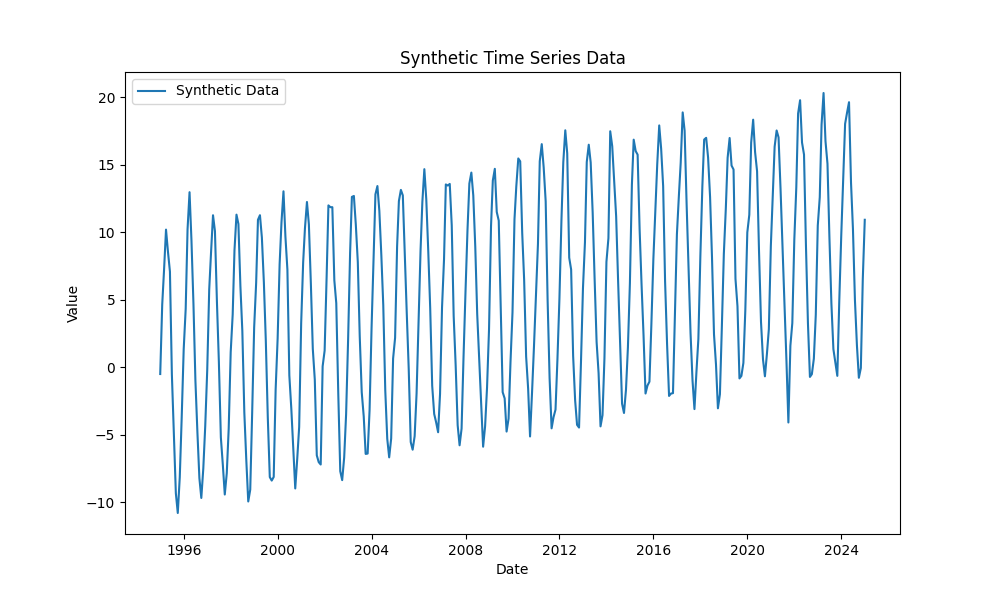

The first set of tests used a small sample, with 3 candidates per generation, and 10 generations, for 30 individuals per experiment. In order to keep this test less time intensive, this test was performed with an integer scale factor of 19, ensuring a maximum of 20 epochs, 20 hidden layers and 20 nodes per layer (and a minimum of 1 of each). The parameters for the PSO were also set to an inertia weighting of 0.7, and both the social and cognitive weightings to 1.5. These values were chosen based on rough guidelines and intended to be a starting point to iterate upon. The results of each test are graphed below.
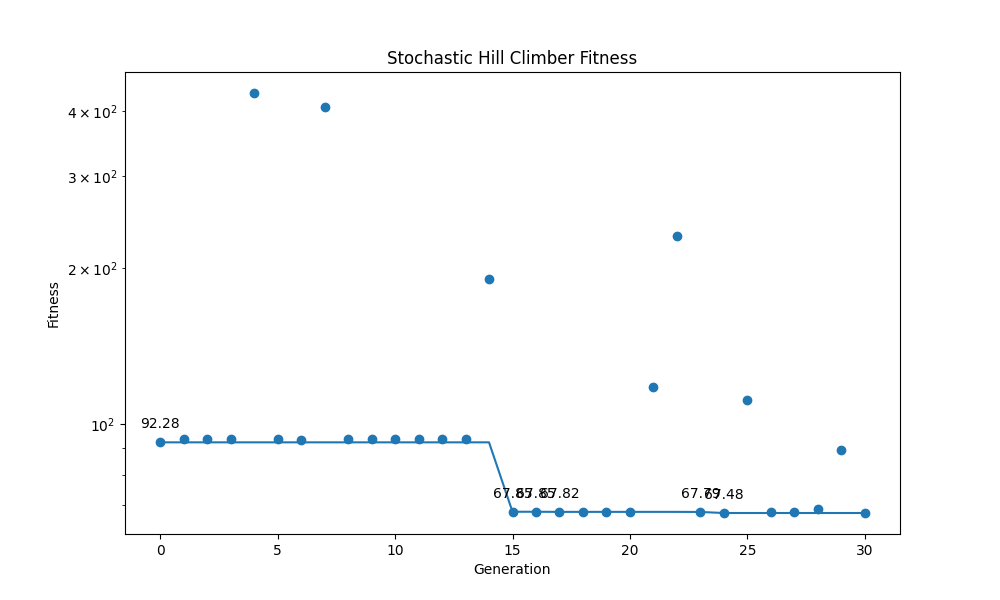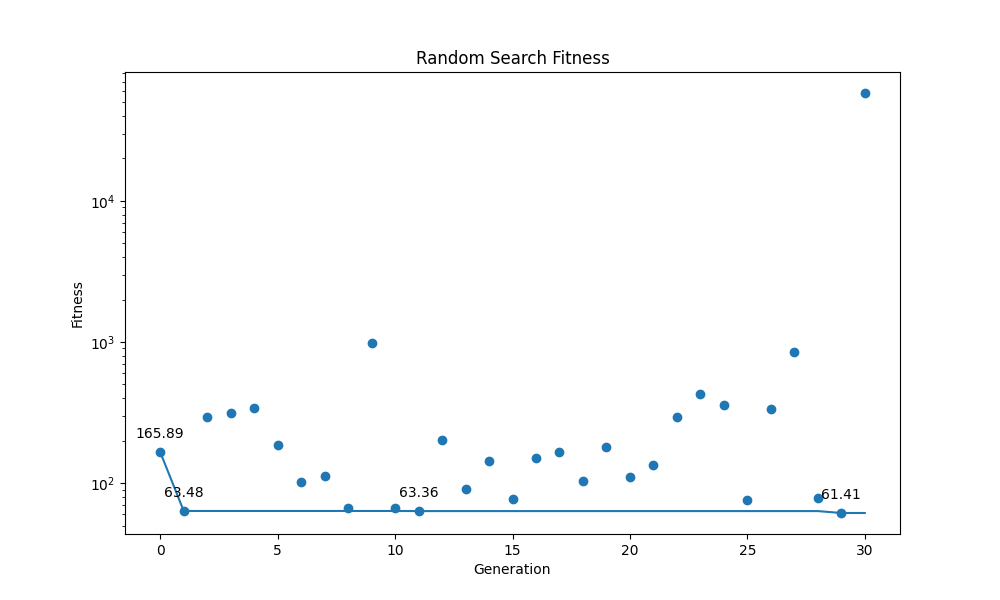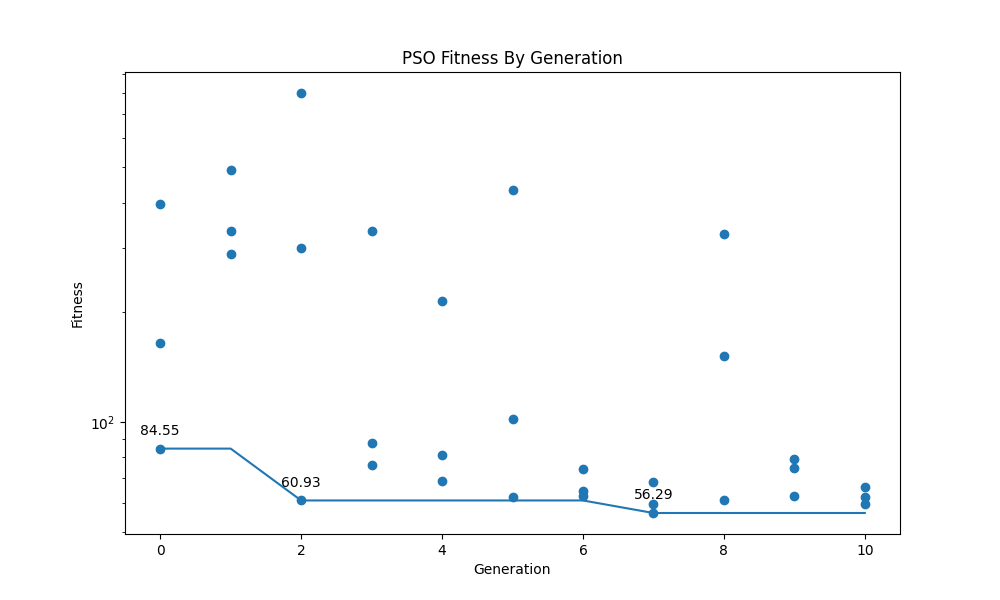


In this experiment, we see the Particle Swarm Optimisation algorithm producing weights that correspond to a hidden layer size of 12, 13 layers, 12 epochs, a dropout rate of 0.866, and a learn rate of 0.101, and achieved a mean squared error of 56.3.
The Random Search algorithm found weights corresponding to a hidden layer size of 17, 9 hidden layers, 11 epochs, a dropout rate of 0.564, and a learn rate of 0.807, achieving a mean squared error of 61.4.
The Stochastic Hill Climber produced weights corresponding to a hidden layer size of 6, 3 hidden layers, 3 epochs, a dropout rate of 0.404, and a learn rate of 0.136, while achieving a mean squared error of 67.5.

In this experiment, despite the sample size being relatively small, we can see the PSO beginning to converge on a solution, and making steady improvements. The SHC, in comparison, makes only one improvement across the iterations, and the random search does not converge at all. The PSO also provides the best solution in this, although as all three solutions are in the same ballpark, which suggests further tests should be carried out to explore their limits.


The second test involved increasing the search space, with the integer scale used being 39 instead of 19, doubling the range of the integer parameters, as well as increasing the iterations to 15 and population size to 5. This leaves 75 individuals in each population, and the social and cognitive weightings for the PSO have been increased to 1.8 to encourage slightly faster converging. The results for these tests are found below.


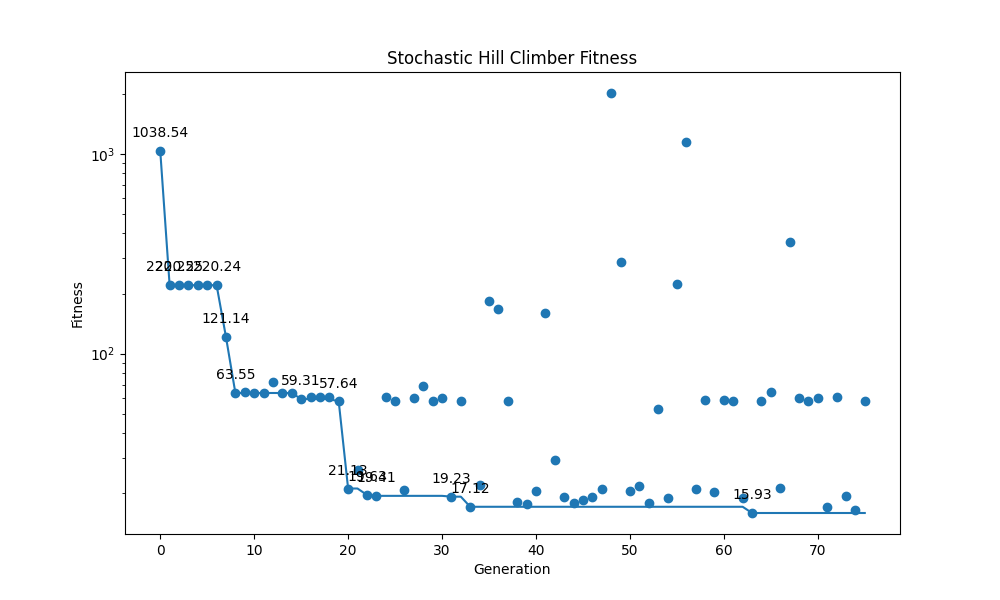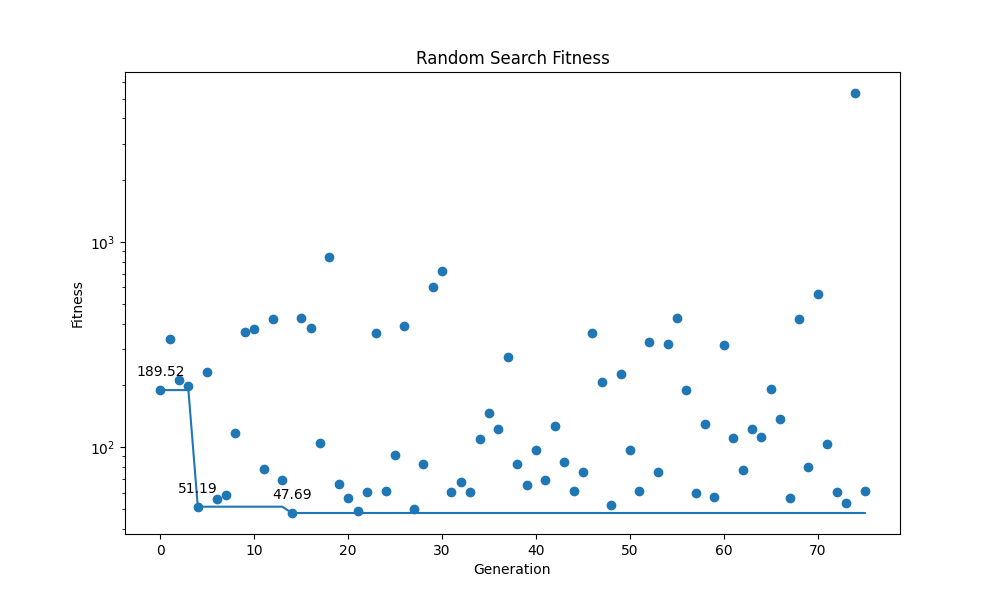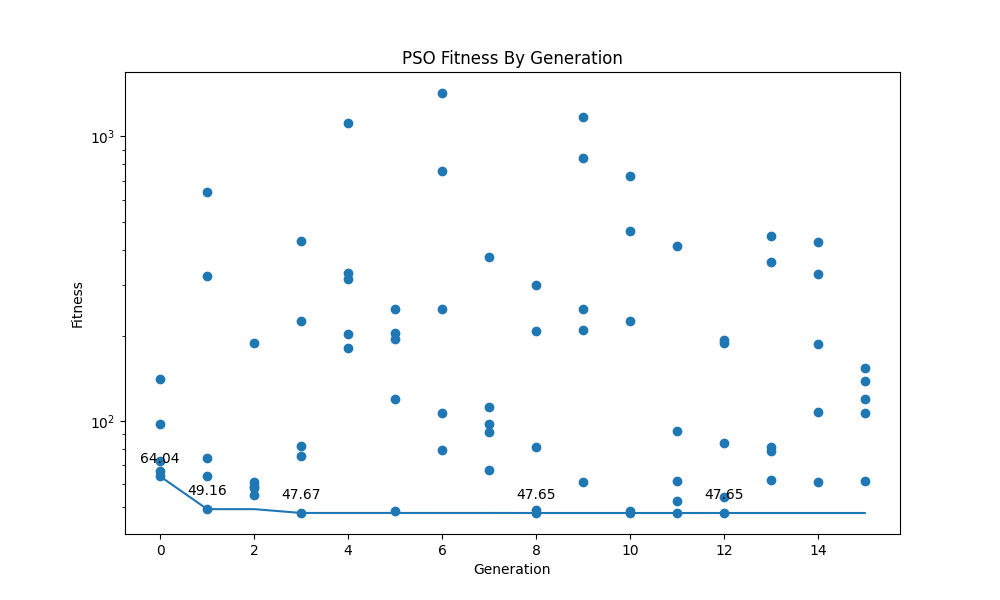

The second test produced results of varying quality. the stochastic hill climber performed notably better than it did in the first test, achieving a mean squared error of just 15.9, with weights correlating to a hidden layer size of 21, 4 layers, 13 epochs, a dropout of 0.280, and a learn rate of 0.0057. It was able to use the larger search space effectively, and climbed to near the top of its local maxima effectively.

Random search achieved a mean squared of 47.6, using a hidden layer size of 13, 16 layers, 26 epochs, a dropout rate of 0.963, and a learn rate of 0.459, and on account of it being an uninformed search, it did not show any convergence, however it does show that the search space is roughly contained between approximately 50 and 10^3.

The Particle Swarm Optimisation, however, performed significantly worse than expected. Instead of converging on a more optimal solution, it produced a result nearly identical to a random search, with a mean squared of 47.6, less than 0.04 better. Additionally, the spread of data points tends to be slightly higher values than the random search. While this would suggest that the search algorithm has failed to converge, a closer look into the values the search algorithm has pushed suggests otherwise. The final results from this test was the maximum integer of 40 for all three of layer count, hidden layer size, and epochs, and this was the case even early on in the searching. During searching the other two values, for dropout rate and learn rate, fluctuated around 1 and 0 respectively, producing a dropout rate of 0.866, and a learn rate of 0.154 at their best value. Because of the trend towards a larger model for a relatively small task, the models these parameters produce are heavily volatile and are not good models.